# BP Subduction 3D - Gmsh Mesh

3D subduction zone mesh for Tandem. All lengths in **km**.

**Coordinate system**
- `x` : fault-normal, horizontal. Trench at x=0, domain spans [-Lx, +Lx]
- `y` : along-strike. Fault centred at y = along_strike/2
- `z` : depth, negative downward. Free surface at z=0

**Fault geometry**

The fault is a rectangle dipping in the x-z plane:
- Top edge (trench): x=0, z=0, y in [0, along_strike]
- Dips toward +x and -z
- Bottom edge at: x = along_dip * cos(dip), z = -along_dip * sin(dip)

The fault is split along dip into two segments:
- **RSF segment**: trench down to `depth_rsf` (rate-and-state friction)
- **Creeping segment**: `depth_rsf` down to full `along_dip`

In [19]:
import numpy as np

# Mesh resolution near the fault
Lf = 5.0          # km - target element size on the fault

# Fault dimensions
along_strike = 200.0   # km - fault extent in y
along_dip    = 150.0   # km - fault extent along the dip direction
dip          = 15.0    # degrees - dip angle from horizontal
depth_rsf    = 60.0    # km - down-dip length of the RSF segment

assert depth_rsf < along_dip, "depth_rsf must be less than along_dip"

dip_rad = np.radians(dip)

# Bounding-box tolerance for post-fragment surface queries
eps = 1e-3   # km

# Fault geometry (derived)
fault_dx     = along_dip * np.cos(dip_rad)   # km - total horizontal reach
fault_dz     = along_dip * np.sin(dip_rad)   # km - total vertical reach (positive)

# RSF segment bottom edge
rsf_dx       = depth_rsf * np.cos(dip_rad)   # km - horizontal reach of RSF segment
rsf_dz       = depth_rsf * np.sin(dip_rad)   # km - vertical reach of RSF segment

print(f"Fault dip:            {dip} deg")
print(f"Along strike:         {along_strike} km")
print(f"Along dip:            {along_dip} km")
print(f"RSF segment:          0 to {depth_rsf} km down-dip")
print(f"Creeping segment:     {depth_rsf} to {along_dip} km down-dip")
print()
print(f"Trench (top edge):    x=0,            z=0")
print(f"RSF bottom edge:      x={rsf_dx:.1f},   z={-rsf_dz:.1f} km")
print(f"Fault bottom edge:    x={fault_dx:.1f},  z={-fault_dz:.1f} km")

Fault dip:            15.0 deg
Along strike:         200.0 km
Along dip:            150.0 km
RSF segment:          0 to 60.0 km down-dip
Creeping segment:     60.0 to 150.0 km down-dip

Trench (top edge):    x=0,            z=0
RSF bottom edge:      x=58.0,   z=-15.5 km
Fault bottom edge:    x=144.9,  z=-38.8 km


## Fault geometry visualization

Quick sanity check before building any Gmsh objects.
The fault dips in the **x-z plane**: the trench sits at x=0, z=0
and the fault bottom edge is at x=fault_dx, z=-fault_dz.

The coordinate axes show the orientation:
- **x** (red)  : fault-normal, horizontal. Positive = away from trench into overriding plate
- **y** (green): along-strike. Fault centred at y=0
- **z** (blue) : vertical. Positive = up, z=0 is the free surface

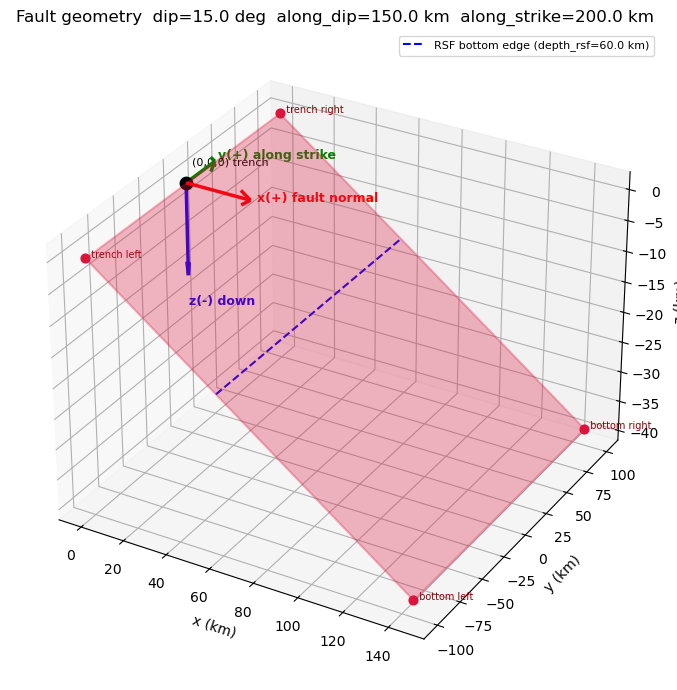

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

# Fault rectangle corners
corners = [
    [0,        -along_strike/2,  0        ],   # trench left
    [0,        +along_strike/2,  0        ],   # trench right
    [fault_dx, +along_strike/2, -fault_dz ],   # bottom right
    [fault_dx, -along_strike/2, -fault_dz ],   # bottom left
]

# Shade the fault surface
fault_poly = Poly3DCollection([corners], alpha=0.3,
                               facecolor='crimson', edgecolor='crimson', linewidth=1.5)
ax.add_collection3d(fault_poly)

# Draw RSF segment bottom edge (dashed line across strike)
ax.plot([rsf_dx, rsf_dx], [-along_strike/2, +along_strike/2], [-rsf_dz, -rsf_dz],
        'b--', linewidth=1.5, label=f'RSF bottom edge (depth_rsf={depth_rsf} km)')

# Label fault corners
for (x, y, z), label in zip(corners, ['trench left', 'trench right', 'bottom right', 'bottom left']):
    ax.scatter(x, y, z, color='crimson', s=40, zorder=5)
    ax.text(x, y, z, '  ' + label, fontsize=7, color='darkred')

# Coordinate axes from origin
L = 30
ax.quiver(0, 0, 0,  L,    0,     0,    color='red',   arrow_length_ratio=0.15, linewidth=2.5)
ax.quiver(0, 0, 0,  0,    L,     0,    color='green', arrow_length_ratio=0.15, linewidth=2.5)
ax.quiver(0, 0, 0,  0,    0,    -L/2,  color='blue',  arrow_length_ratio=0.15, linewidth=2.5)
ax.text(L+3, 0,    0,    'x(+) fault normal', color='red',   fontsize=9, fontweight='bold')
ax.text(0,   L+3,  0,    'y(+) along strike', color='green', fontsize=9, fontweight='bold')
ax.text(0,   0,   -20,   'z(-) down',         color='blue',  fontsize=9, fontweight='bold')

# Mark origin
ax.scatter(0, 0, 0, color='black', s=80, zorder=10)
ax.text(3, 0, 3, '(0,0,0) trench', fontsize=8, color='black')

ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_zlabel('z (km)')
ax.set_title('Fault geometry  dip=' + str(dip) + ' deg  along_dip=' + str(along_dip) + ' km  along_strike=' + str(along_strike) + ' km')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Fault rectangle

Build the fault as a flat planar surface with 4 corners.

| Point | x | y | z |
|-------|---|---|---|
| trench left  | 0 | -along_strike/2 | 0 |
| trench right | 0 | +along_strike/2 | 0 |
| bottom right | fault_dx | +along_strike/2 | -fault_dz |
| bottom left  | fault_dx | -along_strike/2 | -fault_dz |

The four lines are:
- `l_trench` : top edge, along y (the trench)
- `l_dip_right` / `l_dip_left` : the two down-dip edges
- `l_bottom` : bottom edge, along y

In [21]:
import gmsh

gmsh.initialize()
gmsh.model.add('bp_subduction_3d')
gmsh.option.setNumber("General.Terminal", 0)

# Four corners of the fault rectangle
pt_trench_left  = gmsh.model.occ.addPoint(0,         -along_strike/2,  0)
pt_trench_right = gmsh.model.occ.addPoint(0,         +along_strike/2,  0)
pt_bottom_right = gmsh.model.occ.addPoint(fault_dx,  +along_strike/2, -fault_dz)
pt_bottom_left  = gmsh.model.occ.addPoint(fault_dx,  -along_strike/2, -fault_dz)

# Edges
l_trench     = gmsh.model.occ.addLine(pt_trench_left,  pt_trench_right)
l_dip_right  = gmsh.model.occ.addLine(pt_trench_right, pt_bottom_right)
l_bottom     = gmsh.model.occ.addLine(pt_bottom_right, pt_bottom_left)
l_dip_left   = gmsh.model.occ.addLine(pt_bottom_left,  pt_trench_left)

loop_fault   = gmsh.model.occ.addCurveLoop([l_trench, l_dip_right, l_bottom, l_dip_left])
fault_surf   = gmsh.model.occ.addPlaneSurface([loop_fault])

gmsh.model.occ.synchronize()
print(f"fault_surf tag: {fault_surf}")

fault_surf tag: 1


In [23]:
from IPython.display import Image, display
display(Image('SC/1_surface.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

FileNotFoundError: No such file or directory: 'SC/1_surface.png'

FileNotFoundError: No such file or directory: 'SC/1_surface.png'

<IPython.core.display.Image object>

## Split the fault into RSF and creeping segments

The fault is split along-dip at `depth_rsf` **before** the box is created.
This avoids ghost surfaces from multiple fragment operations.

A split line at `(rsf_dx, :, -rsf_dz)` is embedded into the fault surface
using `BooleanFragments`:
- `out_map[0]` -> what the fault surface became (the two segments)
- `out_map[1]` -> what the split line became (the shared edge)

The two segments are identified by center-of-mass x:
- RSF segment: closer to trench, com_x < rsf_dx
- Creeping segment: deeper, com_x > rsf_dx

In [24]:
# Split line at the RSF bottom edge
p_split_left  = gmsh.model.occ.addPoint(rsf_dx, -along_strike/2, -rsf_dz)
p_split_right = gmsh.model.occ.addPoint(rsf_dx, +along_strike/2, -rsf_dz)
split_line    = gmsh.model.occ.addLine(p_split_left, p_split_right)

# Fragment the fault surface with the split line
out_split, out_map_split = gmsh.model.occ.fragment([(2, fault_surf)], [(1, split_line)])
gmsh.model.occ.synchronize()

# Two fault segments from out_map_split[0]
fault_segs = [t for d, t in out_map_split[0]]
if len(fault_segs) != 2:
    raise ValueError(f"Expected 2 fault segments, got: {fault_segs}")

# Identify by center-of-mass x
rsf_surf      = None
creeping_surf = None
for t in fault_segs:
    com_x = gmsh.model.occ.getCenterOfMass(2, t)[0]
    print(f"  Surface {t}: com_x={com_x:.1f}")
    if com_x < rsf_dx:
        rsf_surf = t
    else:
        creeping_surf = t

print(f"rsf_surf:      {rsf_surf}")
print(f"creeping_surf: {creeping_surf}")

  Surface 1: com_x=29.0
  Surface 2: com_x=101.4
rsf_surf:      1
creeping_surf: 2


In [ ]:
from IPython.display import Image, display
display(Image('SC/2_surface.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Domain box

The box is fully defined by the fault geometry:

| dimension | from | to |
|-----------|------|----|
| x | -fault_dx | +fault_dx |
| y | -along_strike/2 | +along_strike/2 |
| z | -fault_dz | 0 |

In [12]:
domain_box = gmsh.model.occ.addBox(
    -fault_dx,       -along_strike/2,  -fault_dz,
     2 * fault_dx,    along_strike,     fault_dz
)

gmsh.model.occ.synchronize()
print(f"domain_box tag: {domain_box}")

domain_box tag: 1


In [ ]:
from IPython.display import Image, display
display(Image('SC/domain.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## BooleanFragments

One single fragment cuts the domain box with **both** fault segments at once.
This produces a clean topology with no ghost surfaces.

`fragment(tool, object)` returns `(out, out_map)`:
- `out_map[0]` -> what the domain box became (the two plate volumes)
- `out_map[1]` -> what rsf_surf became
- `out_map[2]` -> what creeping_surf became

The input order is: `fragment([(3, box)], [(2, rsf), (2, creep)])`,
so `out_map[1]` is the RSF segment and `out_map[2]` is the creeping segment.

In [14]:
# One fragment: box with both fault segments
out, out_map = gmsh.model.occ.fragment(
    [(3, domain_box)],
    [(2, rsf_surf), (2, creeping_surf)]
)
gmsh.model.occ.synchronize()

# --- Fault segments from out_map ---
rsf_frags = out_map[1]
if len(rsf_frags) != 1 or rsf_frags[0][0] != 2:
    raise ValueError(f"Expected rsf_surf to stay as 1 surface, got: {rsf_frags}")
rsf_tag = rsf_frags[0][1]

creep_frags = out_map[2]
if len(creep_frags) != 1 or creep_frags[0][0] != 2:
    raise ValueError(f"Expected creeping_surf to stay as 1 surface, got: {creep_frags}")
creep_tag = creep_frags[0][1]

# --- Upper / lower plate from out_map[0] ---
plate_volumes = [t for d, t in out_map[0]]
print("Center of mass for each plate volume:")
for t in plate_volumes:
    com = gmsh.model.occ.getCenterOfMass(3, t)
    print(f"  Volume {t}: x={com[0]:.2f}, y={com[1]:.2f}, z={com[2]:.2f}")

upper_plate = None
lower_plate = None
for t in plate_volumes:
    com_x = gmsh.model.occ.getCenterOfMass(3, t)[0]
    if com_x > 0:
        upper_plate = t
    else:
        lower_plate = t

print(f"upper_plate volume: {upper_plate}")
print(f"lower_plate volume: {lower_plate}")
print(f"rsf_tag:            {rsf_tag}")
print(f"creep_tag:          {creep_tag}")

Center of mass for each plate volume:
  Volume 1: x=-32.20, y=-0.00, z=-21.57
  Volume 2: x=96.59, y=0.00, z=-12.94
upper_plate volume: 2
lower_plate volume: 1
rsf_tag:            1
creep_tag:          2


## Physical groups

| Tag | What | Description |
|-----|------|-------------|
| 1   | all walls | Free surface (zero traction) |
| 3   | rsf_tag | Rate-and-state friction |
| 5   | creep_tag | Dirichlet / prescribed dislocation |

Free surfaces = everything except the two fault segments.
Both plate volumes go into one physical group (Tandem requires this).

In [15]:
FREE_TAG      = 1
RSF_TAG       = 3
DIRICHLET_TAG = 5

# Free surfaces: everything except the two fault segments
all_surfs = set(t for _, t in gmsh.model.getEntities(dim=2))
free_tags = sorted(all_surfs - {rsf_tag, creep_tag})

# Surfaces (dim=2)
gmsh.model.addPhysicalGroup(2, free_tags,     tag=FREE_TAG)
gmsh.model.addPhysicalGroup(2, [rsf_tag],     tag=RSF_TAG)
gmsh.model.addPhysicalGroup(2, [creep_tag],   tag=DIRICHLET_TAG)

# Volumes (dim=3) - both plates in one group
vol_phys = gmsh.model.addPhysicalGroup(3, [upper_plate, lower_plate])

print(f"Physical Surface({FREE_TAG})  = {free_tags}  <- free ({len(free_tags)} surfaces)")
print(f"Physical Surface({RSF_TAG})  = [{rsf_tag}]  <- RSF fault")
print(f"Physical Surface({DIRICHLET_TAG})  = [{creep_tag}]  <- creeping (Dirichlet)")
print(f"Physical Volume({vol_phys})   = [{upper_plate}, {lower_plate}]  <- domain")

Physical Surface(1)  = [3, 4, 5, 6, 7, 8, 9, 10, 11]  <- free (9 surfaces)
Physical Surface(3)  = [1]  <- RSF fault
Physical Surface(5)  = [2]  <- creeping (Dirichlet)
Physical Volume(6)   = [2, 1]  <- domain


## Mesh size fields

Three gmsh controls are disabled first so element size comes entirely
from the background field:

```python
Mesh.CharacteristicLengthExtendFromBoundary = 0
Mesh.CharacteristicLengthFromPoints         = 0
Mesh.CharacteristicLengthFromCurvature      = 0
```

Two fields drive the mesh size:

**Field 1 - Distance from the RSF fault surface**
Computes 3D distance from every point in the domain to the RSF fault surface.

**Field 2 - Threshold**
- From 0 to `dist_min`: element size = `Lf` (fine, on the fault)
- From `dist_min` to `dist_max`: grows linearly from `Lf` to `Lc`
- Beyond `dist_max`: element size = `Lc` (coarse, far from fault)

```
h
Lc  __|_______
    /
Lf_|
   |----|----|----> distance
   0  dmin  dmax
```

In [16]:
# Disable automatic size hints from geometry
gmsh.option.setNumber('Mesh.CharacteristicLengthExtendFromBoundary', 0)
gmsh.option.setNumber('Mesh.CharacteristicLengthFromPoints',          0)
gmsh.option.setNumber('Mesh.CharacteristicLengthFromCurvature',       0)

Lc       = 20.0    # km - max element size far from the fault
dist_min =  0.0    # km - fine zone: keep Lf up to this distance from fault
dist_max = 80.0    # km - coarse zone: fully at Lc beyond this distance

# Field 1: distance from the RSF fault surface
field_dist = gmsh.model.mesh.field.add('Distance')
gmsh.model.mesh.field.setNumbers(field_dist, 'FacesList', [rsf_tag])

# Field 2: Threshold - Lf at fault, linear growth, caps at Lc
field_thresh = gmsh.model.mesh.field.add('Threshold')
gmsh.model.mesh.field.setNumber(field_thresh, 'InField',   field_dist)
gmsh.model.mesh.field.setNumber(field_thresh, 'SizeMin',   Lf)
gmsh.model.mesh.field.setNumber(field_thresh, 'SizeMax',   Lc)
gmsh.model.mesh.field.setNumber(field_thresh, 'DistMin',   dist_min)
gmsh.model.mesh.field.setNumber(field_thresh, 'DistMax',   dist_max)

gmsh.model.mesh.field.setAsBackgroundMesh(field_thresh)

print(f"h = {Lf} km  from d=0 to d={dist_min} km")
print(f"h grows linearly from {Lf} to {Lc} km  between d={dist_min} and d={dist_max} km")
print(f"h = {Lc} km  beyond d={dist_max} km")

h = 5.0 km  from d=0 to d=0.0 km
h grows linearly from 5.0 to 20.0 km  between d=0.0 and d=80.0 km
h = 20.0 km  beyond d=80.0 km


## Generate and export

Generate a full 3D tetrahedral mesh and write it as a v2.2 `.msh` file.
Tandem requires v2.2.

In [ ]:
gmsh.option.setNumber('Mesh.MshFileVersion', 2.2)

gmsh.model.mesh.generate(3)
gmsh.write('3d.msh')

gmsh.finalize()
print("Mesh written to 3d.msh")

Mesh written to bp_subduction_3d.msh


In [ ]:
from IPython.display import Image, display
display(Image('SC/final_mesh.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Verify mesh with check-bc

Run Tandem's `check-bc` tool on the mesh to confirm all boundary condition tags
are correctly assigned. The output is a VTU file you can open in ParaView.

In [ ]:
import subprocess
import shutil

check_bc = shutil.which('check-bc')
if check_bc is None:
    raise RuntimeError("check-bc not found in PATH")

result = subprocess.run(
    [check_bc, '3', '3d.msh', '3d_bc'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("check-bc passed - open bp_subduction_3d_bc_0.vtu in ParaView to inspect BCs")

RuntimeError: check-bc not found in PATH

In [ ]:
from IPython.display import Image, display
display(Image('SC/paraview_bd.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

# Try on Your Own

### 1. Dipping side walls

The current domain has flat vertical side walls. The goal is a domain whose left
and right walls are parallel to the fault plane, so the perpendicular distance
from the fault to the boundary is constant everywhere.

Create a bigger axis-aligned box, cut it with two tilted planes parallel to the
fault, and remove the two outer volumes with
`gmsh.model.occ.remove([(3, tag)], recursive=True)`.

> **Tip**: The offset from the fault to each cutting plane in x and z is
> `(d * sin(dip), d * cos(dip))`, not `(d, 0)`.

### 2. Different resolution per segment

Currently only the RSF fault drives mesh refinement. The goal is independent
control over element size near the RSF segment and near the creeping segment.

Add a second `Threshold` field driven by `creeping_surf`, then combine both
with a `Min` field and set that as the background mesh.

> **Tip**: The `Min` field picks the finest size from all its inputs at every
> point in the domain — you can stack as many `Threshold` fields as you need.